- Verteilung plotten
- n random samples

In [2]:
import json
import pprint
import random
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

In [2]:
files = sorted(Path("/localdata1/proj_ows/openalex/tagged_and_filtered_snapshot/").rglob("*.jsonl"))

In [3]:
n_works = 0
n_tagged_works = 0
scores = []

for file in tqdm(files):
    with file.open("r") as f:
        for line in f:
            work = json.loads(line)
            sk = work.get("science_keywords")
            if sk:
                scores.append(sk[0][2])
                n_works += 1
                n_tagged_works += 1
            else:
                n_works += 1

print(f"Total works: {n_works:,}, tagged: {n_tagged_works:,}")
print(f"Loss: {n_works - n_tagged_works:,} - {100 * (n_works - n_tagged_works) / n_works:.2f}%")

  0%|          | 0/589 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [5]:
np.save("work_scores.npy", np.array(scores))

In [7]:
x = [np.load("work_scores.npy")]
x[0]

array([0.34071105, 0.45177774, 0.47779269, ..., 0.18116076, 0.57249429,
       0.35189082])

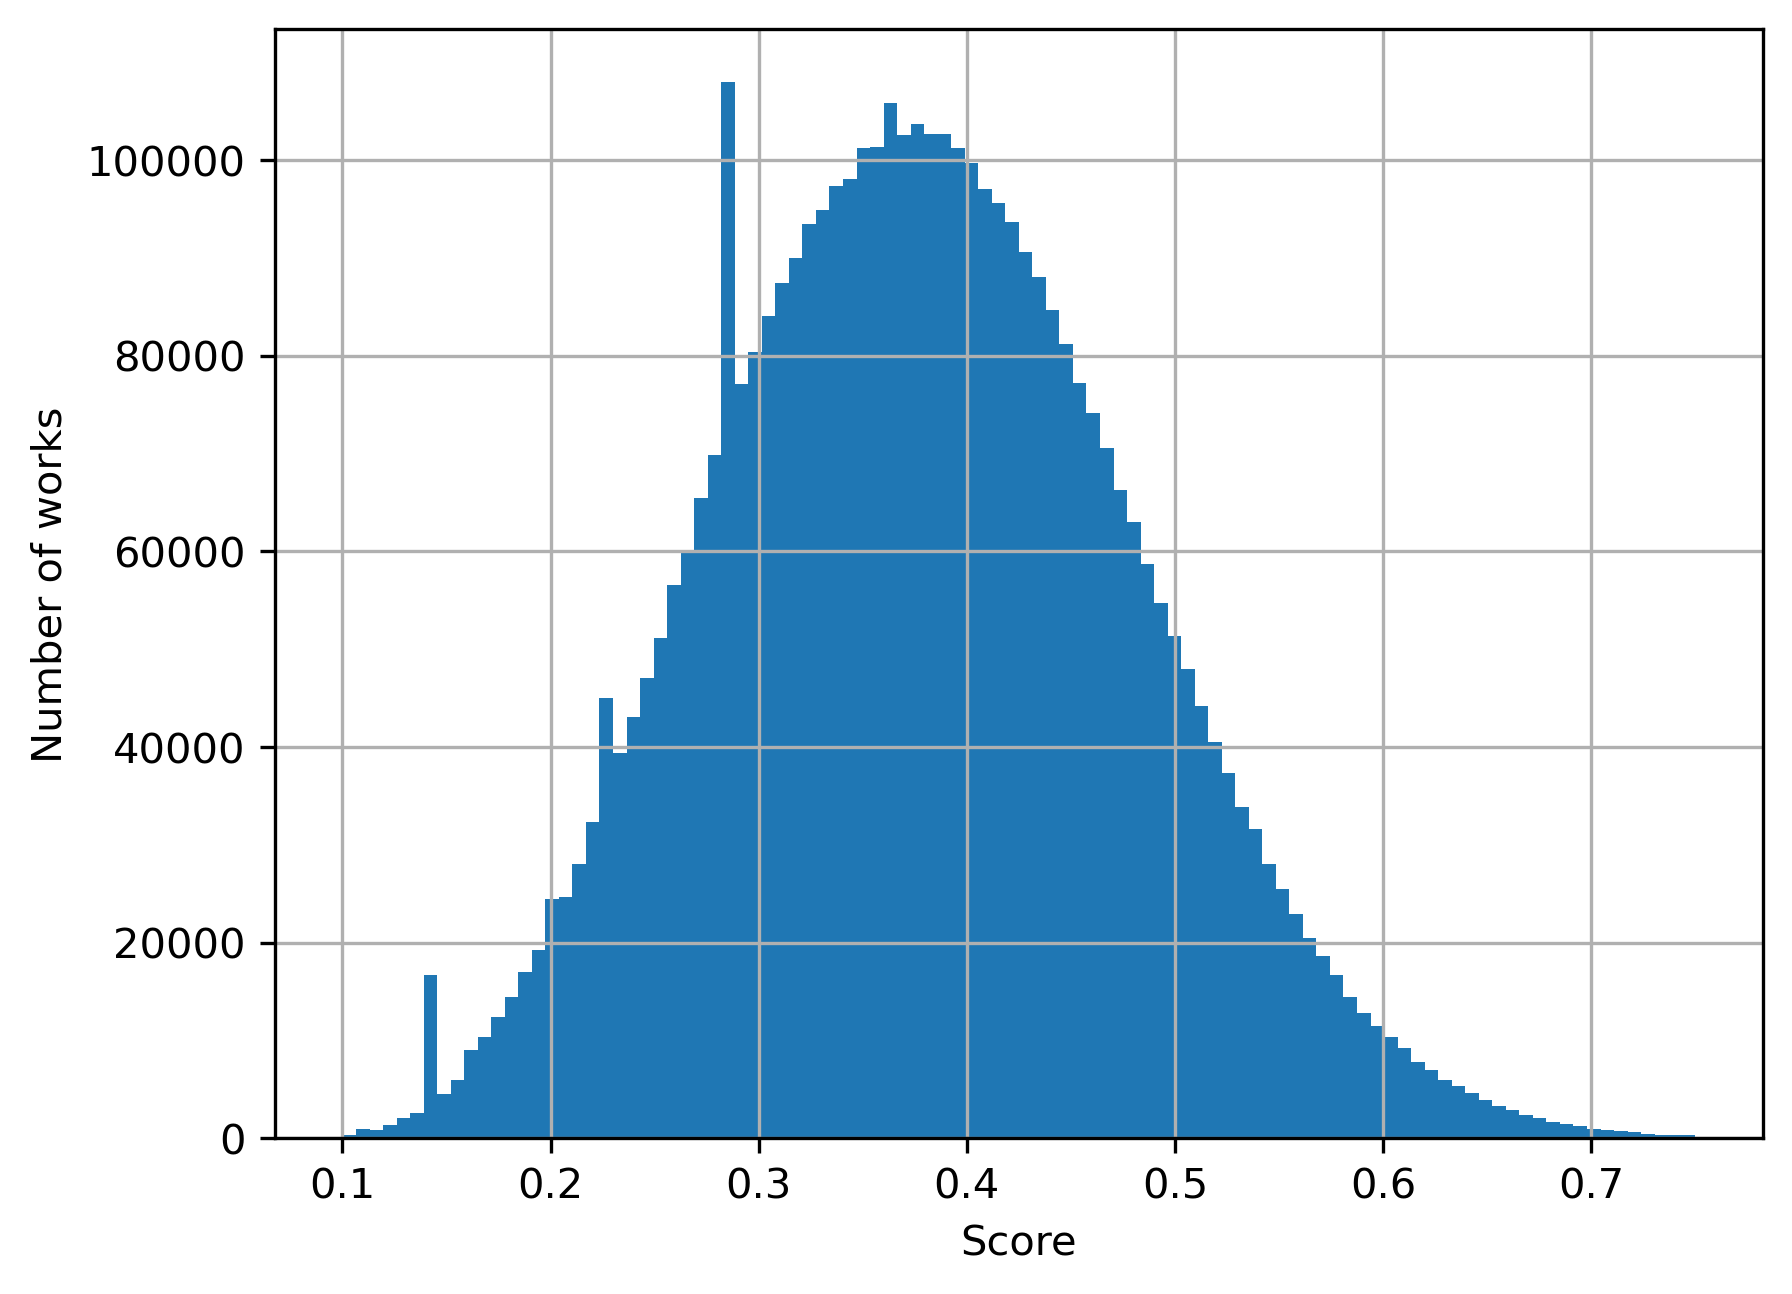

In [8]:
plt.figure(dpi=300)
plt.hist(x, bins=100, range=(0.1, 0.75))
# plt.title("Distribution of highest keyword scores among OpenAlex works")
plt.xlabel("Score")
plt.ylabel("Number of works")
plt.grid(True)
plt.savefig("oa_works_plot.svg")
plt.show()

In [8]:
plt.savefig("oa_works_plot.svg")
plt.show()

<Figure size 640x480 with 0 Axes>

In [5]:
print("Threshold | Works       | Works loss (%)")
print("-" * 40)

for threshold in np.round(np.arange(0.1, 0.5, 0.025), 3):
    works = sum(1 for score in scores if score >= threshold)
    works_loss = 100 * (len(scores) - works) / len(scores)

    print(f"{threshold:9.3f} | {works:>11,} | {works_loss:13.2f}%")

Threshold | Works       | Works loss (%)
----------------------------------------
    0.100 |   4,164,369 |          0.00%
    0.125 |   4,161,099 |          0.08%
    0.150 |   4,136,508 |          0.67%
    0.175 |   4,103,588 |          1.46%
    0.200 |   4,037,355 |          3.05%
    0.225 |   3,928,655 |          5.66%
    0.250 |   3,758,936 |          9.74%
    0.275 |   3,535,055 |         15.11%
    0.300 |   3,212,787 |         22.85%
    0.325 |   2,875,292 |         30.95%
    0.350 |   2,502,090 |         39.92%
    0.375 |   2,105,943 |         49.43%
    0.400 |   1,711,957 |         58.89%
    0.425 |   1,341,460 |         67.79%
    0.450 |   1,009,380 |         75.76%
    0.475 |     728,471 |         82.51%


In [6]:
def get_samples(
    ranges: list[tuple[float, float]],
    n: int = 20
) -> dict[tuple[float, float], list[dict[str, Any]]]:

    reservoirs = {range_: [] for range_ in ranges}
    counts = {range_: 0 for range_ in ranges}

    for file in tqdm(files):
        with file.open("r") as f:
            for line in f:
                work = json.loads(line)
                try:
                    max_score: float = work.get("science_keywords")[0][2]
                except IndexError:
                    continue

                for range_ in ranges:
                    threshold_min, threshold_max = range_
                    if threshold_min < max_score <= threshold_max:
                        counts[range_] += 1
                        if len(reservoirs[range_]) < n:
                            reservoirs[range_].append(work)
                        else:
                            s = random.randint(0, counts[range_] - 1)
                            if s < n:
                                reservoirs[range_][s] = work

    return reservoirs

In [7]:
thresholds = np.round(np.arange(0.1, 0.5, 0.025), 3)
ranges = [(threshold, threshold + 0.025) for threshold in thresholds]

# Get samples for each range
samples = get_samples(ranges, n=20)

  0%|          | 0/589 [00:00<?, ?it/s]

In [8]:
for range_, sample_list in samples.items():
    print(f"Score range: {round(range_[0], 3):.3f} - {round(range_[1], 3):.3f}\n")
    for work in sample_list:

        dict_ = {
            "id": work.get("id"),
            "name": work.get("title"),
            "abstract": work.get("abstract"),
            "best_keyword": (
                work.get("science_keywords", [])[0][0],
                f"{work.get("science_keywords", [])[0][-1]:.3f}"
                )
        }

        pprint.pprint(dict_, width=120, compact=True, sort_dicts=False)

    print("\n\n\n")

Score range: 0.100 - 0.125

{'id': 'https://openalex.org/W2322000045',
 'name': 'Factors accelerating the development of German cockroach (Blattella germanica L.) nymphs reared in groups.',
 'abstract': '集合飼育されたチャバネゴキブリの幼虫は,単独飼育されたものよりも速く発育し集合効果が認められた。集合効果を引き起こす要因を調べるために,七つの飼育実験区(セット1∼7)を設け,単独飼育と集合飼育の幼虫期間と羽化時の生体重を比較した。生体重については,雌雄ともに単独飼育幼虫と集合飼育幼虫とで有意な差はなかった。糞の除去が発育速度に及ぼす影響をみるために,飼育容器中の糞の除去程度を変えて飼育を行った(セット1∼4)。しかし,単独飼育幼虫と集合飼育幼虫の発育速度の差は,糞の除去程度に対応して変化はしなかった。観察者の人為的な刺激によるかく乱に伴いゴキブリが受ける物理的刺激(たとえば接触とか振動)の発育速度への影響をみるため,他のセットより観察の頻度をかなり低くして飼育を行った(セット5, '
             '6)。これらのセットでは,単独飼育幼虫と集合飼育幼虫の発育速度の差は,その他のセットに比べてかなり大きくなった。セット7においては,他個体の臭い刺激を与えた単独飼育幼虫と,与えない単独飼育幼虫の発育速度を比較した結果,臭い刺激を与えたほうが速く発育した。集合した幼虫の発育を促進する要因として,身体的接触刺激と嗅覚刺激が重要であると考えられた。',
 'best_keyword': ('CHEMICAL DECOMPOSITION', '0.116')}
{'id': 'https://openalex.org/W2327516714',
 'name': 'Re-synthesis Mechanisms for PCBs and Chlorobenzenes in Fly Ash by Particle Size',
 'abstract': '一つの飛灰を粒径により分画することで, 組成に特徴のある飛灰が得られることに注目し, 飛灰中のポリ塩化ビフェニル